In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import BatchNormalization

es = EarlyStopping(monitor = "val_loss", mode = "min", patience = 5)

EPOCHS = 100

In [2]:
from keras.preprocessing.image import ImageDataGenerator

root_path = "flowers/"

gen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    validation_split=0.2
)

# Load Data
train_ds = gen.flow_from_directory(
    root_path,
    class_mode="categorical",
    classes = os.listdir(root_path),
    shuffle=True,
    batch_size=32,
    target_size=(128,128),
    subset="training"
)

valid_ds = gen.flow_from_directory(
    root_path,
    class_mode="categorical",
    classes = os.listdir(root_path),
    shuffle=True,
    batch_size=32,
    target_size=(128,128),
    subset="validation"
)

Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.


In [3]:
classes = os.listdir(root_path)

In [4]:
vgg_model = Sequential()

pretrained_model= tf.keras.applications.VGG19(include_top=False,
                   input_shape=(127,127,3),
                   pooling='avg',classes=5,
                   weights='imagenet') #'imagenet'
for layer in pretrained_model.layers:
        layer.trainable=False

vgg_model.add(pretrained_model)

vgg_model.add(Flatten())
vgg_model.add(Dense(5, activation='softmax'))
vgg_model.summary()

2023-01-03 12:36:36.184397: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-03 12:36:36.239448: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-03 12:36:36.239660: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-03 12:36:36.240442: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 512)               20024384  
                                                                 
 flatten (Flatten)           (None, 512)               0         
                                                                 
 dense (Dense)               (None, 5)                 2565      
                                                                 
Total params: 20,026,949
Trainable params: 2,565
Non-trainable params: 20,024,384
_________________________________________________________________


In [5]:
vgg_model.compile(optimizer="adam", loss='categorical_crossentropy',metrics=['accuracy'])

history = vgg_model.fit(train_ds, validation_data=valid_ds, epochs=EPOCHS, callbacks = [es])

Epoch 1/100


2023-01-03 12:36:38.425554: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8700


109/109 [==============================] - 18s 147ms/step - loss: 1.5091 - accuracy: 0.3697 - val_loss: 1.3469 - val_accuracy: 0.5174
Epoch 2/100
109/109 [==============================] - 15s 135ms/step - loss: 1.2519 - accuracy: 0.5664 - val_loss: 1.1920 - val_accuracy: 0.5849
Epoch 3/100
109/109 [==============================] - 15s 136ms/step - loss: 1.1133 - accuracy: 0.6196 - val_loss: 1.1012 - val_accuracy: 0.6291
Epoch 4/100
109/109 [==============================] - 14s 131ms/step - loss: 1.0290 - accuracy: 0.6465 - val_loss: 1.0289 - val_accuracy: 0.6326
Epoch 5/100
109/109 [==============================] - 15s 138ms/step - loss: 0.9852 - accuracy: 0.6624 - val_loss: 0.9832 - val_accuracy: 0.6535
Epoch 6/100
109/109 [==============================] - 15s 135ms/step - loss: 0.9348 - accuracy: 0.6798 - val_loss: 0.9414 - val_accuracy: 0.6616
Epoch 7/100
109/109 [==============================] - 15s 139ms/step - loss: 0.9117 - accuracy: 0.6757 - val_loss: 0.9162 - val_accurac

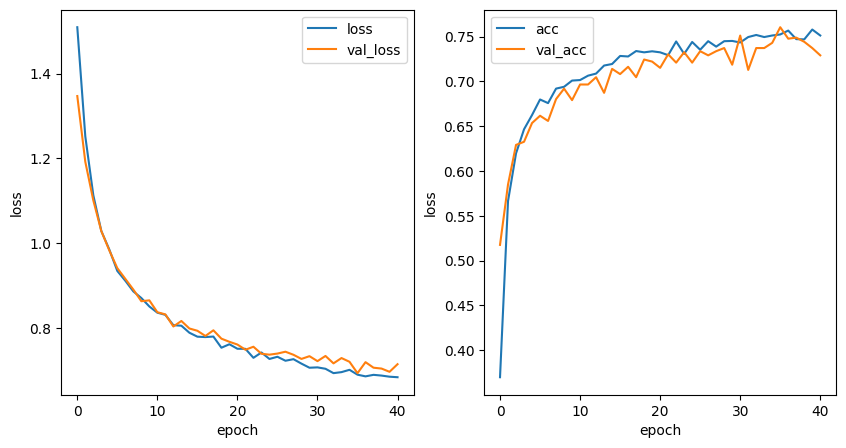

In [6]:
hist = pd.DataFrame(history.history)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(hist.loss, label = "loss")
plt.plot(hist.val_loss, label = "val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist.accuracy, label = "acc")
plt.plot(hist.val_accuracy, label = "val_acc")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()